# Detect discontinuities in storm tracks

This notebook scans the connected storm-track DataFrames for each simulation (`ERA5`, `UBB`, `UBD`, `UBE`, `UBF`, `UBG`, `UBH`, `UBI`) and flags lines that look physically inconsistent within a single storm (same storm ID).

Types of discontinuity checked (all between two consecutive points of the **same storm**, ordered by the `point` column):

1. **Time gap** different from +1 h (includes going backwards, duplicates, and gaps).
2. **Latitude jump** > 1°.
3. **Longitude jump** > 1° (handled modulo 360 so the -180↔180 seam is ignored).
4. **Pressure jump** > 2 hPa.
5. **Longitude convention mixing**: a storm that contains both lon values < -10 and lon values > 190 (clear sign that the Fortran algorithm swapped between the -180:180 and 0:360 grids for the same track).

The goal here is purely **diagnostic**: produce a per-simulation count, identify the worst storms, and persist a CSV of every suspect line so a correction step can be built on top of it later.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from ETC_tools import open_df

In [2]:
SIMS = ['ERA5', 'UBB', 'UBD', 'UBE', 'UBF', 'UBG', 'UBH', 'UBI']

# Thresholds
LAT_THRESHOLD = 10.0      # degrees
LON_THRESHOLD = 10.0      # degrees (after modulo-360 wrapping)
PRES_THRESHOLD = 8.0     # hPa
EXPECTED_DT = pd.Timedelta(hours=1)

OUTPUT_DIR = '/home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/KATJA/OUTPUTS/DISCONTINUITIES'
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [3]:
def wrapped_lon_diff(lon_a, lon_b):
    """Absolute longitude difference accounting for wrap-around.

    Works whether the inputs are in -180:180 or 0:360. For a same-storm
    convention flip (e.g. -112.03 -> 247.97) this returns ~0, which is the
    correct physical answer. Convention mixing is detected separately below.
    """
    d = np.abs(lon_a - lon_b) % 360.0
    return np.minimum(d, 360.0 - d)


def detect_storm_discontinuities(df, sim):
    """Return a DataFrame of suspect rows (one row per flagged transition).

    df is assumed to be the output of ETC_tools.open_df, i.e. columns
    [storm, point, i, j, date, lat, lon, pressure] with `date` as datetime.
    """
    # Sort inside each storm by point number — this is the algorithm's own
    # trajectory order, which is what we want to audit. Sorting by date
    # would hide the bug (the date column itself can be wrong).
    df = df.sort_values(['storm', 'point']).reset_index(drop=True)

    g = df.groupby('storm', sort=False)

    # Next-row values within each storm (NaN at the last point of each storm)
    lat_next = g['lat'].shift(-1)
    lon_next = g['lon'].shift(-1)
    date_next = g['date'].shift(-1)
    pres_next = g['pressure'].shift(-1)
    storm_next = g['storm'].shift(-1)

    same_storm = df['storm'] == storm_next

    dlat = (lat_next - df['lat']).abs()
    dlon = wrapped_lon_diff(lon_next.values, df['lon'].values)
    dt = (date_next - df['date'])
    dp = (pres_next - df['pressure']).abs()

    flag_lat = same_storm & (dlat > LAT_THRESHOLD)
    flag_lon = same_storm & (pd.Series(dlon, index=df.index) > LON_THRESHOLD)
    flag_dt = same_storm & (dt != EXPECTED_DT)
    flag_pres = same_storm & (dp > PRES_THRESHOLD)

    any_flag = flag_lat | flag_lon | flag_dt | flag_pres

    suspects = df.loc[any_flag, ['storm', 'point', 'date', 'lat', 'lon', 'pressure']].copy()
    suspects['next_date'] = date_next[any_flag].values
    suspects['next_lat'] = lat_next[any_flag].values
    suspects['next_lon'] = lon_next[any_flag].values
    suspects['next_pressure'] = pres_next[any_flag].values
    suspects['dlat'] = dlat[any_flag].values
    suspects['dlon_wrapped'] = pd.Series(dlon, index=df.index)[any_flag].values
    suspects['dt'] = dt[any_flag].values
    suspects['dpressure'] = (pres_next - df['pressure'])[any_flag].values
    suspects['flag_lat'] = flag_lat[any_flag].values
    suspects['flag_lon'] = flag_lon[any_flag].values
    suspects['flag_dt'] = flag_dt[any_flag].values
    suspects['flag_pres'] = flag_pres[any_flag].values
    suspects['sim'] = sim

    # Convention-mixing check at the storm level
    has_neg = g['lon'].min() < -10.0
    has_high = g['lon'].max() > 190.0
    mixed_storms = has_neg.index[(has_neg & has_high).values].tolist()

    return suspects, mixed_storms

In [4]:
all_suspects = []
summary_rows = []
mixed_storms_per_sim = {}

for sim in SIMS:
    print(f'\n=== {sim} ===')
    df = open_df(sim, period_filtering=False)

    suspects, mixed_storms = detect_storm_discontinuities(df, sim)
    mixed_storms_per_sim[sim] = mixed_storms

    n_total_rows = len(df)
    n_total_storms = df['storm'].nunique()
    n_flagged_transitions = len(suspects)
    n_flagged_storms = suspects['storm'].nunique()

    summary_rows.append({
        'sim': sim,
        'n_rows': n_total_rows,
        'n_storms': n_total_storms,
        'n_flagged_transitions': n_flagged_transitions,
        'n_flagged_storms': n_flagged_storms,
        'pct_storms_flagged': 100 * n_flagged_storms / max(n_total_storms, 1),
        'n_lon_convention_mixed_storms': len(mixed_storms),
        'n_time_flags': int(suspects['flag_dt'].sum()),
        'n_lat_flags': int(suspects['flag_lat'].sum()),
        'n_lon_flags': int(suspects['flag_lon'].sum()),
        'n_pres_flags': int(suspects['flag_pres'].sum()),
    })

    suspects.to_csv(f'{OUTPUT_DIR}/discontinuities_{sim}.csv', index=False)
    all_suspects.append(suspects)
    print(f'  storms={n_total_storms}, flagged storms={n_flagged_storms} '
          f'({100*n_flagged_storms/max(n_total_storms,1):.2f}%), '
          f'flagged transitions={n_flagged_transitions}, '
          f'lon-convention-mixed storms={len(mixed_storms)}')

summary = pd.DataFrame(summary_rows)
# summary.to_csv(f'{OUTPUT_DIR}/summary.csv', index=False)
summary


=== ERA5 ===
  storms=21847, flagged storms=45 (0.21%), flagged transitions=49, lon-convention-mixed storms=0

=== UBB ===
  storms=20538, flagged storms=10 (0.05%), flagged transitions=10, lon-convention-mixed storms=0

=== UBD ===
  storms=16976, flagged storms=19 (0.11%), flagged transitions=19, lon-convention-mixed storms=0

=== UBE ===
  storms=16294, flagged storms=10 (0.06%), flagged transitions=10, lon-convention-mixed storms=0

=== UBF ===
  storms=18849, flagged storms=15 (0.08%), flagged transitions=15, lon-convention-mixed storms=0

=== UBG ===
  storms=55575, flagged storms=79 (0.14%), flagged transitions=80, lon-convention-mixed storms=0

=== UBH ===
  storms=55612, flagged storms=62 (0.11%), flagged transitions=63, lon-convention-mixed storms=0

=== UBI ===
  storms=60897, flagged storms=50 (0.08%), flagged transitions=51, lon-convention-mixed storms=0


,sim,n_rows,n_storms,n_flagged_transitions,n_flagged_storms,pct_storms_flagged,n_lon_convention_mixed_storms,n_time_flags,n_lat_flags,n_lon_flags,n_pres_flags
0,ERA5,1118658,21847,49,45,0.205978,0,0,0,46,3
1,UBB,1118696,20538,10,10,0.048690,0,0,0,10,0
2,UBD,956178,16976,19,19,0.111923,0,0,0,19,0
3,UBE,917331,16294,10,10,0.061372,0,0,0,10,0
4,UBF,1116505,18849,15,15,0.079580,0,0,0,15,0
5,UBG,3185781,55575,80,79,0.142150,0,0,0,80,0
6,UBH,3132421,55612,63,62,0.111487,0,0,0,63,0
7,UBI,3677189,60897,51,50,0.082106,0,0,0,51,0


## Top storms by number of flagged transitions

Useful to eyeball the worst offenders and decide if they are isolated single-point glitches or full track corruption.

In [5]:
all_suspects_df = pd.concat(all_suspects, ignore_index=True)

top_per_sim = (all_suspects_df
               .groupby(['sim', 'storm']).size()
               .rename('n_flags')
               .reset_index()
               .sort_values(['sim', 'n_flags'], ascending=[True, False])
               .groupby('sim').head(10))
top_per_sim

,sim,storm,n_flags
26,ERA5,11742,3
14,ERA5,7463,2
38,ERA5,19704,2
0,ERA5,385,1
1,ERA5,2188,1
...,...,...,...
244,UBI,7486,1
245,UBI,7609,1
246,UBI,8442,1
247,UBI,8647,1


In [6]:
# Quick sanity: show the UBI 2067 storm 255 transition that motivated this notebook
ubi_suspects = all_suspects_df[(all_suspects_df['sim'] == 'UBI') & (all_suspects_df['storm'] == 28426)]
ubi_suspects.head(20)

,storm,point,date,lat,lon,pressure,next_date,next_lat,next_lon,next_pressure,dlat,dlon_wrapped,dt,dpressure,flag_lat,flag_lon,flag_dt,flag_pres,sim


## Distribution of flag types per simulation

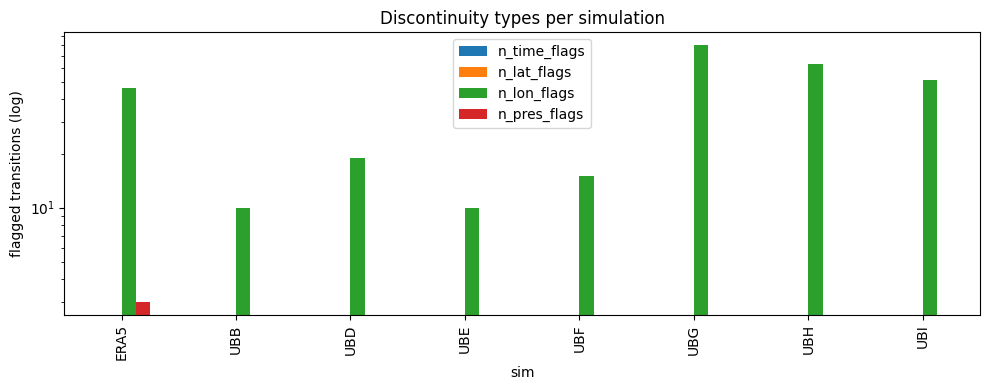

In [7]:
flag_cols = ['n_time_flags', 'n_lat_flags', 'n_lon_flags', 'n_pres_flags']
summary.set_index('sim')[flag_cols].plot(kind='bar', figsize=(10, 4), logy=True)
plt.ylabel('flagged transitions (log)')
plt.title('Discontinuity types per simulation')
plt.tight_layout()
plt.show()

## Inspect one flagged storm visually

Plot lat, lon, pressure along the `point` axis for the most-flagged storm of one simulation, so it's easy to see whether the issue is a single spike, a trajectory split, or interleaved tracks.

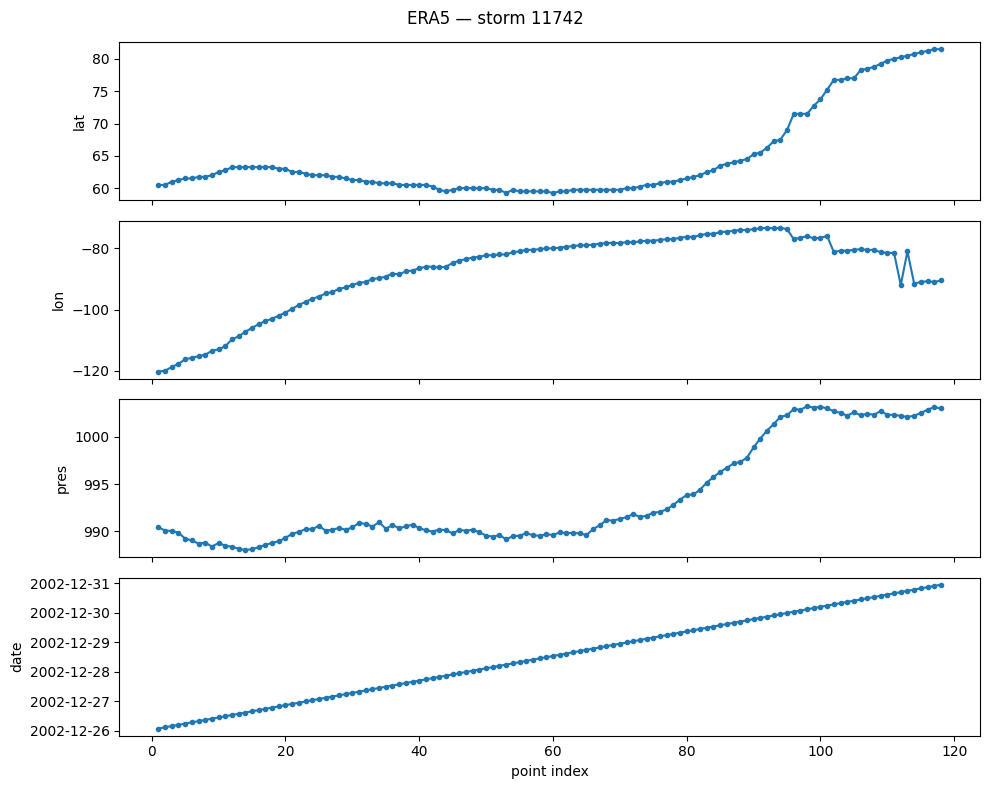

In [8]:
def plot_storm(sim, storm_id):
    df = open_df(sim, period_filtering=False)
    s = df[df['storm'] == storm_id].sort_values('point')

    fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
    axes[0].plot(s['point'], s['lat'], marker='.'); axes[0].set_ylabel('lat')
    axes[1].plot(s['point'], s['lon'], marker='.'); axes[1].set_ylabel('lon')
    axes[2].plot(s['point'], s['pressure'], marker='.'); axes[2].set_ylabel('pres')
    axes[3].plot(s['point'], s['date'], marker='.'); axes[3].set_ylabel('date')
    axes[-1].set_xlabel('point index')
    fig.suptitle(f'{sim} — storm {storm_id}')
    plt.tight_layout()
    plt.show()

if len(top_per_sim) > 0:
    row = top_per_sim.iloc[0]
    plot_storm(row['sim'], int(row['storm']))

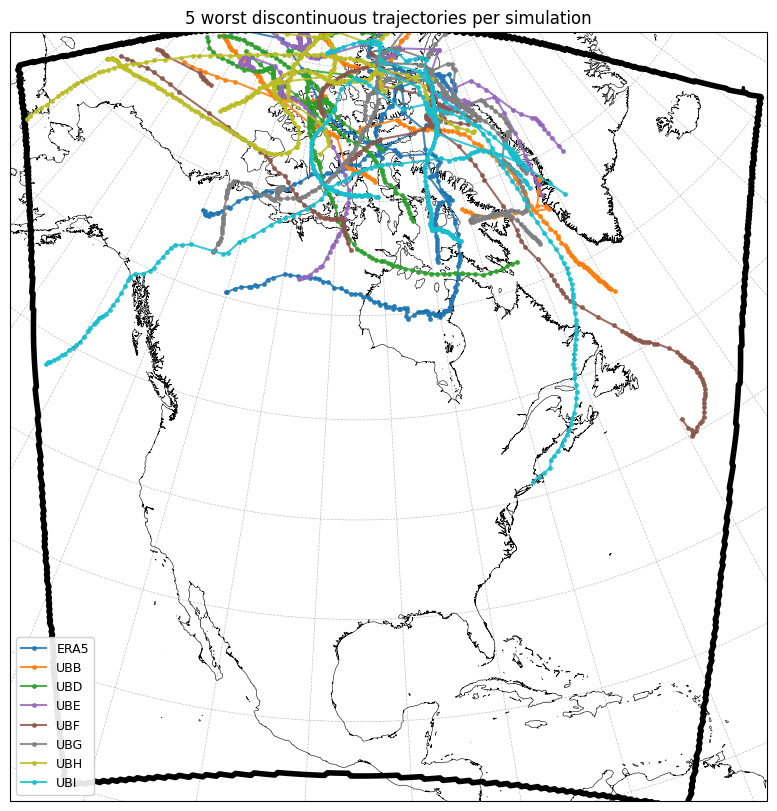

In [11]:
import cartopy
import cartopy.crs as ccrs

# Before 2015, UBG/UBH/UBI share their tracks with UBD/UBE/UBF respectively,
# so restrict those three sims to post-2015 flags to avoid double-counting.
POST2015_SIMS = {'UBG', 'UBH', 'UBI'}
CUTOFF = pd.Timestamp('2015-01-01')

ranking_df = all_suspects_df.copy()
mask_drop = ranking_df['sim'].isin(POST2015_SIMS) & (ranking_df['date'] < CUTOFF)
ranking_df = ranking_df[~mask_drop]

top5_per_sim = (ranking_df
                .groupby(['sim', 'storm']).size()
                .rename('n_flags')
                .reset_index()
                .sort_values(['sim', 'n_flags'], ascending=[True, False])
                .groupby('sim').head(5))

sim_colors = dict(zip(SIMS, plt.cm.tab10(np.linspace(0, 1, len(SIMS)))))

plotcrs = ccrs.LambertConformal(central_latitude=45, central_longitude=-95)
fig, ax = plt.subplots(1, 1, subplot_kw={'projection': plotcrs},
                       figsize=(11, 8), constrained_layout=True)

ax.coastlines(resolution='10m', linewidth=0.4, color='black')
ax.gridlines(linewidth=0.5, linestyle='--', color='k', alpha=0.25,
             xlocs=range(-180, 180, 10), ylocs=range(-90, 90, 10))
ax.set_extent([-128, -56, 81, 12], crs=ccrs.PlateCarree())

import xarray as xr
ds = xr.open_dataset('/home/vdemeyer/projects/rrg-gachon/vdemeyer/MASK/mask_CRCM6_grid_for_ERA5_0_360_eroded.nc')
ax.contour(ds.longitude, ds.latitude, ds.mask.astype(int),
           levels=[0.5], colors='black', linewidths=4,
           transform=ccrs.PlateCarree())

legend_seen = set()
for sim in SIMS:
    df = open_df(sim, period_filtering=False)
    storms = top5_per_sim.loc[top5_per_sim['sim'] == sim, 'storm'].tolist()
    for storm_id in storms:
        g = df[df['storm'] == storm_id].sort_values('point')
        label = sim if sim not in legend_seen else None
        legend_seen.add(sim)
        ax.plot(g['lon'].values, g['lat'].values,
                color=sim_colors[sim], lw=1.5, alpha=0.85,
                marker='o', markersize=2.5,
                transform=ccrs.Geodetic(),
                label=label)

ax.legend(loc='lower left', fontsize=9, framealpha=0.9)
ax.set_title('5 worst discontinuous trajectories per simulation')
plt.show()

## Notes on the Fortran algorithm

The example given (`UBI` year 2067, storm 255) shows several symptoms in one storm:
- the date goes **backwards** between consecutive points (2067090413 → 2067090501 → 2067090502 → **2067090421** → **2067090417**),
- longitudes jump by tens of degrees (-47.89 → -111.88) and also switch convention (247.97 appears mid-track among -40° values),
- pressure jumps by 28 hPa in one step.

This is not a single-point smoothing glitch — it looks like distinct tracks being concatenated under the same storm ID. The most likely culprits in `storm_tracks.f90` are the track-matching step (nearest-candidate selection across time steps) and the storm-ID reuse logic across month boundaries. That's worth inspecting in the Fortran side once we have the full list of affected storms from the CSVs written above.